In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd 
import numpy as np
pd.set_option("display.max_columns", None)      # view ALL columns in DataFrames
# pd.reset_option("display.max_columns")        # reset to default
from pypalettes import load_cmap
# personalisation
plt.rcParams.update({
    "font.family": "Georgia",
    "font.size": 11,
    "lines.linewidth": 1,
})

# Import Data

In [2]:
df = pd.read_parquet("../data/strava_activities.parquet")

keep = [
    "activity_id", "name", "type",
    "start_datetime", "end_datetime",
    "date", "year", "month", "week", "weekday", "start_hour",
    "distance_km", "distance_miles",
    "moving_time_mins", "elapsed_time_mins",
    "avg_pace_km", "avg_pace_mile",
    "avg_hr", "max_hr", "avg_cadence_spm",
    "total_elev_gain",
    "shoe", "num_comments", "num_achievements", "num_kudos"
]

# analyze running activities only
df = df[keep].loc[df["type"] == "Run"]     

# remove extremely short runs (sprints, cool-downs, etc.)
df = df.loc[df["distance_km"] >= 1.0]

# infer avg_hr from activity name for activities where hr_zone is "Unknown"
mask = (df["name"].str.contains("bpm")) & (df["avg_hr"].isna())

df.loc[mask, "avg_hr"] = (
    df.loc[mask, "name"]
    .str.extract(r"(\d{3}) bpm")[0]     # extract the first (and only) capture group
    .astype(float)
)

# create a category for heart rate zones 
max_hr = 220 

conditions = [
    df["avg_hr"] < 0.6 * max_hr,                            # Zone 1 (Warm-up/Recovery)
    df["avg_hr"].between(0.6 * max_hr, 0.7 * max_hr),       # Zone 2 (Easy/Endurance)
    df["avg_hr"].between(0.7 * max_hr, 0.8 * max_hr),       # Zone 3 (Aerobic/Tempo)
    df["avg_hr"].between(0.8 * max_hr, 0.9 * max_hr),       # Zone 4 (Threshold/Interval)
    df["avg_hr"].between(0.9 * max_hr, 1.0 * max_hr)        # Zone 5 (VO2 Max)
]
choices = ["Zone 1", "Zone 2", "Zone 3", "Zone 4", "Zone 5"]

df["hr_zone"] = np.select(conditions, choices, default="Unknown")

df["hr_zone"].value_counts()

hr_zone
Zone 3     365
Unknown    191
Zone 2     125
Zone 4      41
Name: count, dtype: int64

# Scatter Graph

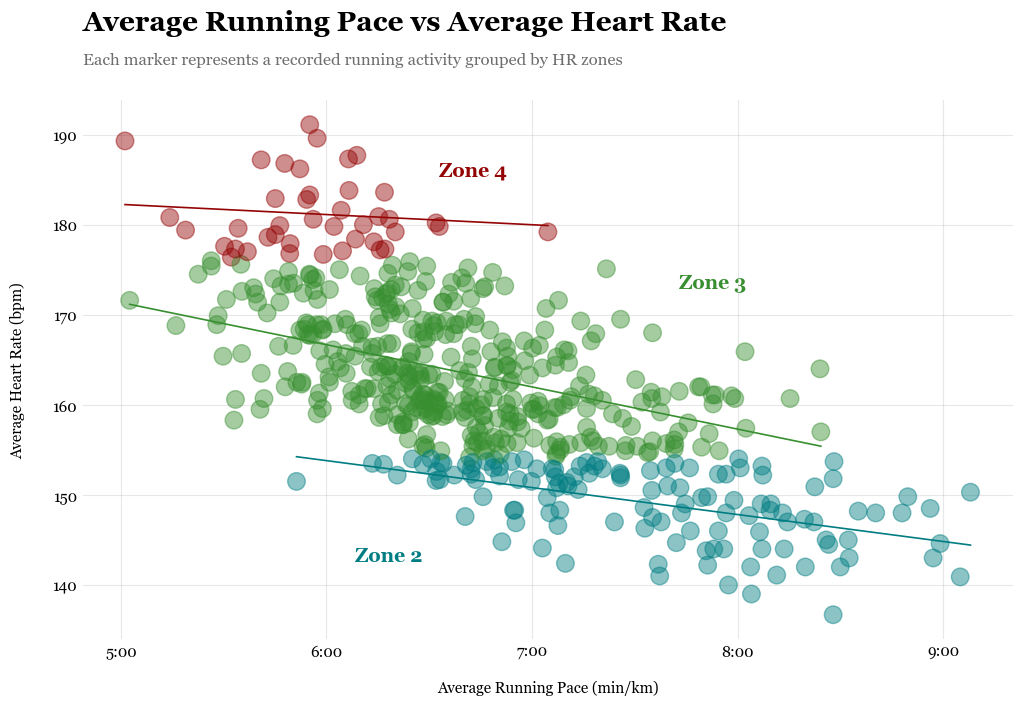

In [5]:
# colour palette
cmap = load_cmap("Abbott")
colours = cmap.colors

# define custom colours for each zone
df = df.loc[df["hr_zone"] != "Unknown"]    # filter out "Unknown" zone
zone_colours = {
    "Zone 1": colours[0],
    "Zone 2": colours[6],
    "Zone 3": colours[4],
    "Zone 4": colours[0],
    "Zone 5": colours[4],
    # "Unknown": "#6e6e6e"
}

# map colours to dataframe
point_colours = df["hr_zone"].map(zone_colours)

# create a figure for visualisation
fig, ax = plt.subplots(figsize=(12, 7))

# axes customisation
ax.grid(True, alpha=0.3, zorder=0)
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.tick_params(length=0)

def pace_formatter(x, pos):
    """Convert pace in minutes per km to string format "M:SS" (e.g., 4.5 to "4:30")."""
    minutes = int(x)
    seconds = int(round((x - minutes) * 60))
    return f"{minutes}:{seconds:02d}"

ax.xaxis.set_major_formatter(mticker.FuncFormatter(pace_formatter))

# # optional: add horizontal lines to indicate HR zone boundaries
# zone_bounds = [
#     # 0.6 * max_hr,
#     0.7 * max_hr,
#     0.8 * max_hr,
#     0.9 * max_hr,
#     # 1.0 * max_hr
# ]
# for bound in zone_bounds:
#     ax.axhline(
#         y=bound,
#         linestyle=(0, (8, 8)),
#         linewidth=1,
#         color="#6e6e6e",
#         alpha=0.3,
#         zorder=1
#     )

# scatter plot (pace vs heart rate)
sns.scatterplot(
    data=df, x="avg_pace_km", y="avg_hr",
    hue="hr_zone", palette=zone_colours,
    s=160, alpha=0.45, edgecolor=None,
    legend=False, ax=ax, zorder=4
)

# regression line per group
for zone, sub_df in df.groupby("hr_zone"):
    sns.regplot(
        data=sub_df,
        x="avg_pace_km",
        y="avg_hr",
        scatter=False,
        ax=ax,
        color=zone_colours[zone],  # match colour to group
        line_kws={
            "linewidth": 1.2,
            # "alpha": 0.9,
            # "linestyle": (0, (8, 4))
        },
        ci=None
    )

# # overall regression line to show overall trend
# sns.regplot(
#     data=df, x="avg_pace_km", y="avg_hr",
#     scatter=False, ax=ax,ci=None,
#     color="black",
#     line_kws={
#         "linewidth": 1.5, 
#         # "alpha": 0.7
#     },
# )

# text labels
pos = {
    "Zone 1": (0.5, 0.3),
    "Zone 2": (0.38, 0.23),
    "Zone 3": (0.65, 0.62),
    "Zone 4": (0.45, 0.78),
    "Zone 5": (0.5, 0.3)
}

for i, zone in enumerate(df["hr_zone"].unique()):
    fig.text(
        x=pos[zone][0], y=pos[zone][1], 
        s=zone, fontsize=14, weight="bold",
        color=zone_colours[zone],
        ha="center", va="center"
    )

# title
x_value, y_value = 0.125, 0.98
fig.text(
    x=x_value, y=y_value,
    s=f"Average Running Pace vs Average Heart Rate",
    fontsize=20,
    weight="bold"
)

# subtitle
fig.text(
    x=x_value,
    y=y_value * 0.95,
    s="Each marker represents a recorded running activity grouped by HR zones",
    size=12,
    color="#6e6e6e"
)

ax.set_xlabel("Average Running Pace (min/km)", labelpad=15)
ax.set_ylabel("Average Heart Rate (bpm)", labelpad=20)

plt.savefig("../images/avg_pace_vs_heart_rate.svg", bbox_inches="tight")

plt.show()

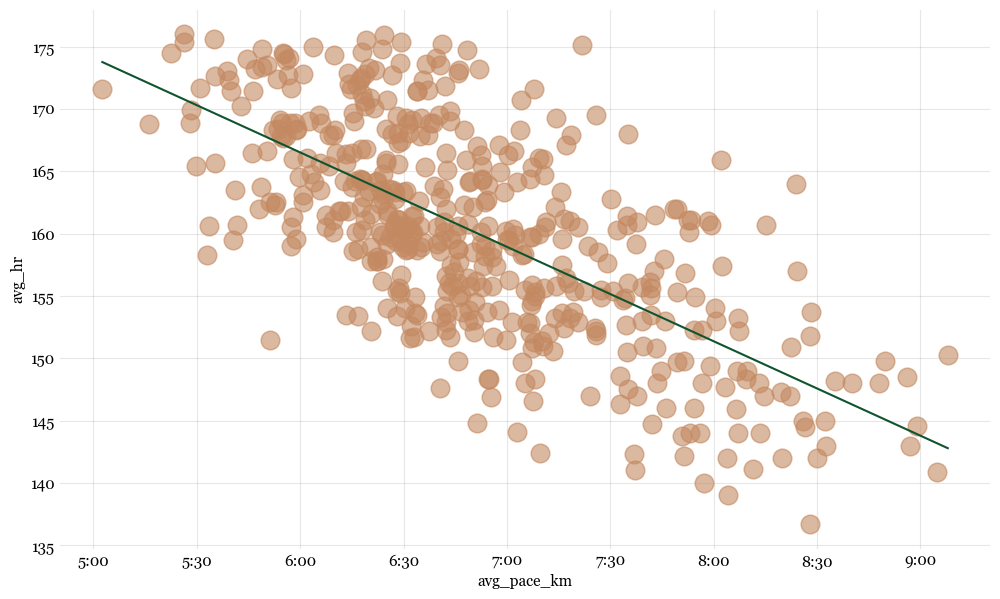

In [9]:
# filter for specific zones
zones_to_plot = [
    "Zone 2", 
    "Zone 3"
]

df_subset = df.loc[df["hr_zone"].isin(zones_to_plot)]

fig, ax = plt.subplots(figsize=(12, 7))

ax.grid(True, alpha=0.3, zorder=0)
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.tick_params(length=0)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(pace_formatter))

# scatter (single colour)
sns.scatterplot(
    data=df_subset,
    x="avg_pace_km",
    y="avg_hr",
    color=colours[2],
    s=180,
    alpha=0.6,
    edgecolor=None,
    ax=ax,
    zorder=2
)

# single regression line
sns.regplot(
    data=df_subset,
    x="avg_pace_km",
    y="avg_hr",
    scatter=False,
    ax=ax,
    ci=None,
    color=colours[5],
    line_kws={"linewidth": 1.5}
)

plt.show()